# RetailRocket: experiment report

Purchase-target Hawkes (multi-type history) vs **scaled seasonal baseline** (fair `mu` via MLE).


In [1]:
%matplotlib inline
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RESULTS_ROOT = ROOT / 'results/retailrocket'
print('ROOT:', ROOT)
print('RESULTS_ROOT:', RESULTS_ROOT)


ROOT: /Users/amosh239/repo/mkn/Hawk's proccess
RESULTS_ROOT: /Users/amosh239/repo/mkn/Hawk's proccess/results/retailrocket


In [2]:
import pandas as pd
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

# Choose a run (defaults to the latest retailrocket-YYYYMMDD-HHMMSS folder).
RUN_ID = 'retailrocket-20260126-183513'  # set to None to auto-pick latest
runs = sorted(RESULTS_ROOT.glob('retailrocket-*'))
if not runs:
    raise FileNotFoundError('No runs found. Run: .venv/bin/python scripts/run_real.py --dataset retailrocket')
RUN_DIR = (RESULTS_ROOT / RUN_ID) if RUN_ID else runs[-1]
SUMMARY_PATH = RUN_DIR / 'summary.csv'

df = pd.read_csv(SUMMARY_PATH)
print('RUN_DIR:', RUN_DIR)
print('rows:', len(df))
df.head(5)


RUN_DIR: /Users/amosh239/repo/mkn/Hawk's proccess/results/retailrocket/retailrocket-20260126-183513
rows: 78


,seq_id,n_events,train_events,test_events,purchases_train,purchases_test,test_hours,ll_unit,ll_baseline,ll_hawkes,ll_gain,mu_baseline,mu_hawkes,mu,alpha_type_0,alpha_type_1,alpha_type_2
0,3258,26,23,3,2,0,17.797517,per_hour,-1.046913e-08,-1.046913e-08,-4.310278e-15,1.000000,1.000000,1.000000,0.000000,0.000000,0.0
1,6699,104,79,25,2,2,2.035775,per_hour,-1.812788e+01,-1.812788e+01,1.742074e-07,1.340170,1.340170,1.340170,0.000000,0.000000,0.0
2,11333,52,47,5,2,0,432.326706,per_hour,-2.976191e-03,-3.343551e-09,2.976187e-03,0.890129,0.000001,0.000001,0.000000,1.464495,0.0
3,12579,165,155,10,2,0,596.200962,per_hour,-1.507682e-03,-2.178802e-04,1.289802e-03,0.017972,0.000001,0.000001,0.033663,0.000000,5.0
4,17676,274,175,99,27,15,41.522170,per_hour,-1.323814e+00,2.499139e-01,1.573728e+00,0.842379,0.000001,0.000001,0.000000,5.000000,0.0


## Metrics
Notes:
- `ll_unit=per_hour`: we compute test log-likelihood per hour of the test window.
- `ll_gain = ll_hawkes - ll_baseline`: positive means Hawkes is better.


In [3]:
wins = (df.ll_gain > 0)
p0 = (df.purchases_test == 0)

def pct(x):
    return 100.0 * float(x)

print('win rate (overall):', f'{pct(wins.mean()):.1f}%')
print('win rate (purchases_test==0):', f'{pct(wins[p0].mean()):.1f}%' if p0.any() else 'n/a')
print('win rate (purchases_test>0):', f'{pct(wins[~p0].mean()):.1f}%' if (~p0).any() else 'n/a')

print('purchases_test==0 share:', f'{pct(p0.mean()):.1f}%')
print('median ll_gain:', float(df.ll_gain.median()))
print('mean ll_gain:', float(df.ll_gain.mean()))
print('median test_hours:', float(df.test_hours.median()))


win rate (overall): 78.2%
win rate (purchases_test==0): 70.9%
win rate (purchases_test>0): 95.7%
purchases_test==0 share: 70.5%
median ll_gain: 0.00888024754670105
mean ll_gain: -2.248836198837291
median test_hours: 314.07824138888884


## Plots

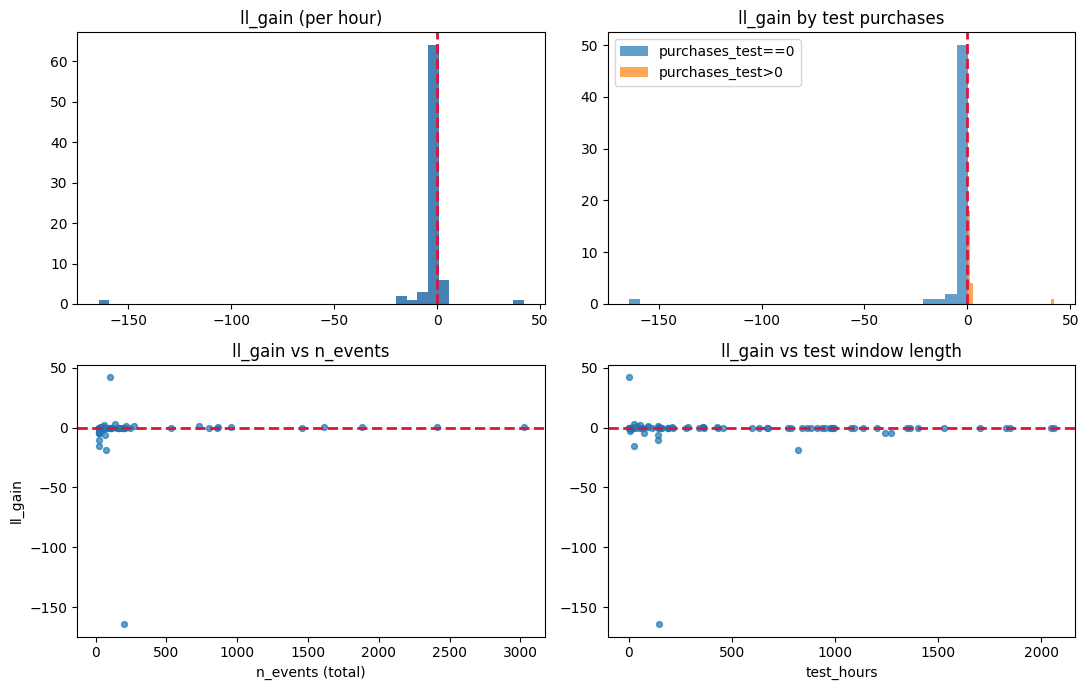

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(11, 7))

# ll_gain histogram
ax[0, 0].hist(df.ll_gain, bins=40, color='steelblue')
ax[0, 0].axvline(0, color='crimson', linestyle='--', linewidth=2)
ax[0, 0].set_title('ll_gain (per hour)')

# ll_gain histogram by purchases_test==0
ax[0, 1].hist(df.loc[p0, 'll_gain'], bins=30, alpha=0.7, label='purchases_test==0')
ax[0, 1].hist(df.loc[~p0, 'll_gain'], bins=30, alpha=0.7, label='purchases_test>0')
ax[0, 1].axvline(0, color='crimson', linestyle='--', linewidth=2)
ax[0, 1].set_title('ll_gain by test purchases')
ax[0, 1].legend()

# scatter: ll_gain vs n_events
ax[1, 0].scatter(df.n_events, df.ll_gain, s=18, alpha=0.7)
ax[1, 0].axhline(0, color='crimson', linestyle='--', linewidth=2)
ax[1, 0].set_xlabel('n_events (total)')
ax[1, 0].set_ylabel('ll_gain')
ax[1, 0].set_title('ll_gain vs n_events')

# scatter: ll_gain vs test_hours
ax[1, 1].scatter(df.test_hours, df.ll_gain, s=18, alpha=0.7)
ax[1, 1].axhline(0, color='crimson', linestyle='--', linewidth=2)
ax[1, 1].set_xlabel('test_hours')
ax[1, 1].set_title('ll_gain vs test window length')

plt.tight_layout()


## Fitted alpha (by event type)
For the purchase-target model we keep 3 excitation parameters:
- `alpha_type_0` (view -> purchase)
- `alpha_type_1` (addtocart -> purchase)
- `alpha_type_2` (transaction -> purchase)


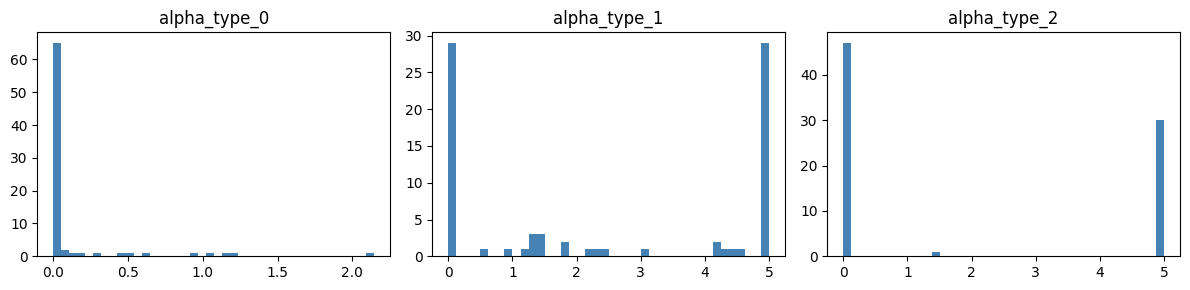

In [5]:
alpha_cols = ['alpha_type_0', 'alpha_type_1', 'alpha_type_2']
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
for i, c in enumerate(alpha_cols):
    ax[i].hist(df[c].values, bins=40, color='steelblue')
    ax[i].set_title(c)
plt.tight_layout()


## Best / worst sequences

In [6]:
cols = ['seq_id', 'n_events', 'purchases_train', 'purchases_test', 'test_hours', 'll_gain']
print('Top 10 by ll_gain:')
display(df.sort_values('ll_gain', ascending=False)[cols].head(10))
print('Bottom 10 by ll_gain:')
display(df.sort_values('ll_gain', ascending=True)[cols].head(10))


Top 10 by ll_gain:


,seq_id,n_events,purchases_train,purchases_test,test_hours,ll_gain
36,109357,101,12,7,3.676451,42.074267
68,175801,139,7,6,24.242313,2.740473
6,22990,58,7,4,53.967943,2.094695
23,57905,732,13,31,140.775903,1.690073
4,17676,274,27,15,41.522170,1.573728
22,55389,213,2,5,92.114777,1.118664
77,198270,956,64,40,91.885906,0.851645
54,152963,3024,264,85,359.813392,0.663971
29,76757,1883,89,96,359.720951,0.594887
59,163561,2410,48,44,288.445801,0.469741


Bottom 10 by ll_gain:


,seq_id,n_events,purchases_train,purchases_test,test_hours,ll_gain
64,171718,203,33,0,148.752444,-164.355402
52,150651,71,8,0,818.940958,-18.786985
14,38103,25,7,0,24.519881,-15.475984
47,144274,22,2,0,142.210104,-9.936517
38,115257,70,5,0,143.828624,-5.905726
40,128147,25,2,0,72.646492,-4.603124
26,72254,22,2,0,1272.406069,-4.514286
8,24722,22,3,0,1244.356952,-4.053098
51,149854,24,4,0,7.849350,-2.470480
11,31645,53,3,0,11.674195,-1.343082


## Why so many `purchases_test==0`?
Because purchases are rare. The notebook `notebooks/retailrocket_dataset_qa.ipynb` shows how this depends on `train_ratio` and `min_events`.

If you want more test purchases, try a larger test window (smaller train_ratio), e.g.:
```bash
.venv/bin/python scripts/run_real.py --dataset retailrocket --train-ratio 0.6 --min-events 30 --min-purchases-train 1 --max-seqs 500
```
